In [14]:
# commpute wasserstain's distance (earth mover's distance) to quantify if there is significant drift
# imagine two distributions, having equal number of data points, and sorted
# then wasserstein's distance == average absolute differene between corresponding points
# or, what is the average distance per point? 
# starting from the first dist,
# if you either add or subtract "wasserstein's distance" to each data point
# on average, then you get the second distribution. Also known as Earth's mover's distance 

import pickle
import sqlite3
import numpy as np

# user inputs

model = "geosfp" #"merra2"
id_string = "inst3_3d_chm_Nv|CO2|1.0|Strat2" #"inst3_3d_asm_Nv|RH|22.0|Strat7"
year1, month1 = 2025, 1
year2, month2 = 2025, 2

# code

db_path = (
    f"/home/sadhika8/JupyterLinks/nobackup/quads_database/"
    f"{model}_monthly_aggregated_centroids_and_quantiles.db"
)

with sqlite3.connect(f"file:{db_path}?mode=ro", uri=True) as conn:

    def get(model, year, month, idstr):
        table = model

        row = conn.execute(
            f"""
            SELECT quantiles, quantile_list
            FROM {table}
            WHERE model = ? AND year = ? AND month = ? AND id_string = ?
            """,
            (model.upper(), year, month, idstr),
        ).fetchone()

        if row is None:
            return None

        return pickle.loads(row[0]), pickle.loads(row[1])

    a = get(model, year1, month1, id_string)
    b = get(model, year2, month2, id_string)


if a is None or b is None:
    print(
        f"Missing row: "
        f"{year1}-{month1:02d}={a is not None}, "
        f"{year2}-{month2:02d}={b is not None}"
    )
    raise SystemExit(1)



In [15]:
qa, qlist_a = a
qb, qlist_b = b

#print(f"Quantile lists identical: {qlist_a == qlist_b}")
#print(f"Unpickled quantiles equal: {qa == qb}")

#print(f"\n{year1}-{month1:02d}: {qa}")
#print(f"{year2}-{month2:02d}: {qb}")


wasserstein = np.trapz(
    np.abs(np.asarray(qa) - np.asarray(qb)),
    np.asarray(qlist_a),
)

mean_a = np.mean(qa)
std_a = np.std(qa)

mean_b = np.mean(qb)
std_b = np.std(qb)

normalized_wasserstein = wasserstein / mean_a

print(f"\n{year1}-{month1:02d}:")
print(f"  mean: {mean_a}")
print(f"  std:  {std_a}")

print(f"\n{year2}-{month2:02d}:")
print(f"  mean: {mean_b}")
print(f"  std:  {std_b}")

print(f"\nWasserstein distance:            {wasserstein}")
print(f"Mean Normalized Wasserstein distance: {normalized_wasserstein}")


2025-01:
  mean: 0.00042521439714802593
  std:  1.8929136859969364e-07

2025-02:
  mean: 0.0004254314815190421
  std:  1.3223737063607443e-07

Wasserstein distance:            2.3363750628866668e-07
Mean Normalized Wasserstein distance: 0.000549458127137056


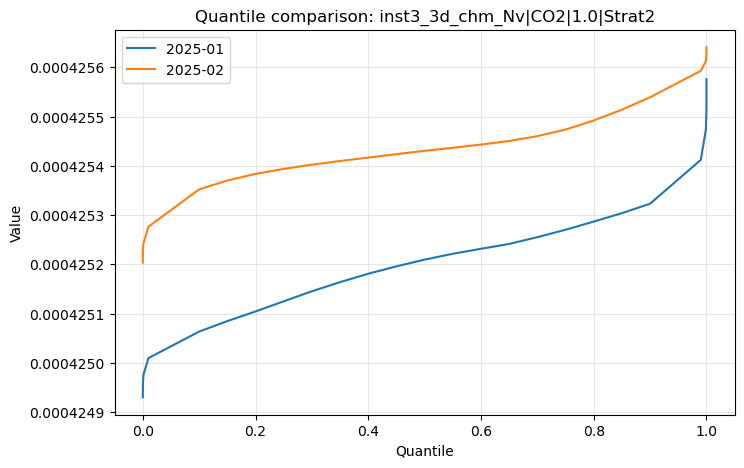

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(qlist_a, qa, label=f"{year1}-{month1:02d}")
plt.plot(qlist_b, qb, label=f"{year2}-{month2:02d}")

plt.xlabel("Quantile")
plt.ylabel("Value")
plt.title(f"Quantile comparison: {id_string}")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [17]:
## if you want to answer how significant that is purely based on statistical ground
## do the following
## load raw data for both months 
## compute Wasserstein distance, true wasserstein distance, you can use standard library
## do the following bootstraping experiment
## a) mix both data randomly, and from the total data randomly pick two groups
## b) compute wasserstein distance and repeat the process several times, like 1000 times
## c) Construct confidence interval - at 90, 95, and 99
## 

In [18]:
# create histogram from monthly data

In [19]:
from calendar import monthrange
from datetime import datetime

import dask.array as da
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from get_collections_and_files import list_files_and_excluded_vars


def monthly_rawdata_for_collection(
    model,
    year,
    month,
    collection,
    var,
    data_yaml_file,
    lat_name="lat",
    lev_name="lev",
    lat_min=-90,
    lat_max=-70,
    level=None,
):
    all_files = []
    excluded = []

    for day in range(1, monthrange(year, month)[1] + 1):
        _, collection_map, excluded_vars = list_files_and_excluded_vars(
            model=model,
            date=datetime(year, month, day),
            data_yaml_file=data_yaml_file,
        )

        all_files.extend(collection_map.get(collection, []))

        if not excluded:
            excluded = excluded_vars

    print(f"Found {len(all_files)} files for collection {collection}")

    ds = xr.open_mfdataset(
        all_files[:1],
        combine="by_coords",
        drop_variables=excluded,
        data_vars="minimal",
        coords="minimal",
        compat="no_conflicts",
        engine="h5netcdf",
        chunks="auto",
        parallel=True,
    )

    da_var = ds[var]

    lat_vals = da_var[lat_name].values
    if lat_vals[0] <= lat_vals[-1]:
        da_var = da_var.sel({lat_name: slice(lat_min, lat_max)})
    else:
        da_var = da_var.sel({lat_name: slice(lat_max, lat_min)})

    if level is not None and lev_name in da_var.dims:
        da_var = da_var.sel({lev_name: level})

    arr = da_var.data
    arr = da.where(da.isfinite(arr), arr, np.nan)
    
    n = da.sum(~da.isnan(arr)).compute()
    mean_val = da.nanmean(arr).compute()
    std_val = da.nanstd(arr).compute()
    min_val = da.nanmin(arr).compute()
    max_val = da.nanmax(arr).compute()

    print("N:", int(n))
    print("mean:", float(mean_val))
    print("std:", float(std_val))
    print("min:", float(min_val))
    print("max:", float(max_val))

    #finite_vals = arr.ravel()[~da.isnan(arr.ravel())]
    
    flat = arr.ravel()
    finite_vals = flat[da.isfinite(flat)]
    ds.close()
    
    return finite_vals


In [20]:
raw_data = monthly_rawdata_for_collection(
    model="GEOSFP",
    year=2024,
    month=2,
    collection="inst1_2d_hwl_Nx",
    var="CO2CL",
    data_yaml_file="/home/sadhika8/JupyterLinks/nobackup/quads/conf/dataserver.yaml",
    lat_name="lat",
    lat_min=-90,
    lat_max=-70,
    level=None,
)

GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D01
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D02
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D03
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D04
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D05
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D06
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D07
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D08
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D09
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D10


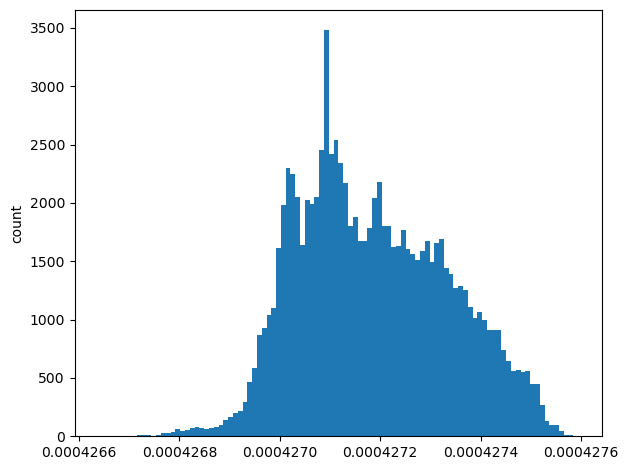

In [21]:
min_val = np.min(raw_data)
max_val = np.max(raw_data)

hist, bin_edges = da.histogram(
        raw_data,
        bins=100,
        range=(float(min_val), float(max_val)),
    )
hist = hist.compute()

plt.figure()
plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), align="edge")
#plt.title(f"Histogram: {var}")
#plt.xlabel(var)
plt.ylabel("count")
plt.tight_layout()
plt.show()

In [22]:
data1 = monthly_rawdata_for_collection(
    model="GEOSFP",
    year=2024,
    month=2,
    collection="inst1_2d_hwl_Nx",
    var="CO2CL",
    data_yaml_file="/home/sadhika8/JupyterLinks/nobackup/quads/conf/dataserver.yaml",
    lat_name="lat",
    lat_min=-90,
    lat_max=-70,
    level=None,
)

data2 = monthly_rawdata_for_collection(
    model="GEOSFP",
    year=2025,
    month=2,
    collection="inst1_2d_hwl_Nx",
    var="CO2CL",
    data_yaml_file="/home/sadhika8/JupyterLinks/nobackup/quads/conf/dataserver.yaml",
    lat_name="lat",
    lat_min=-90,
    lat_max=-70,
    level=None,
)

GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D01
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D02
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D03
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D04
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D05
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D06
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D07
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D08
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D09
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D10


In [23]:
# Wasserstein distance
from scipy.stats import wasserstein_distance

def compute_wasserstein(data1, data2):
    return wasserstein_distance(data1, data2)

In [24]:
compute_wasserstein(data1, data2)

1.5353571077851977e-06

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def permutation_test(data1, data2, N=1000):
    data1 = np.asarray(data1, dtype=float)   # convert once, not per-iteration
    data2 = np.asarray(data2, dtype=float)
    n1 = data1.size
    pooled = np.concatenate([data1, data2])

    null_dist = np.empty(N)
    for i in range(N):
        shuffled = np.random.permutation(pooled)
        null_dist[i] = compute_wasserstein(shuffled[:n1], shuffled[n1:])

    ci = {lvl: tuple(np.percentile(null_dist, [(100 - lvl) / 2, 100 - (100 - lvl) / 2]))
          for lvl in (90, 95, 99)}

    colors = {90: "green", 95: "orange", 99: "red"}
    plt.hist(null_dist, bins=30, color="steelblue", edgecolor="white")
    for lvl, (lo, hi) in ci.items():
        plt.axvline(lo, color=colors[lvl], linestyle="--", label=f"{lvl}% CI")
        plt.axvline(hi, color=colors[lvl], linestyle="--")
    plt.legend()
    plt.xlabel("Wasserstein distance (permuted)")
    plt.title(f"Permutation null distribution (N={N})")
    plt.show()

    observed_wasserstein = compute_wasserstein(data1, data2)
    print(f"Observed Wasserstein Distance: {observed_wasserstein}")
    
    for lvl, (lo, hi) in ci.items():
        print(f"{lvl}% CI: [{lo}, {hi}]")

    #return null_dist, ci

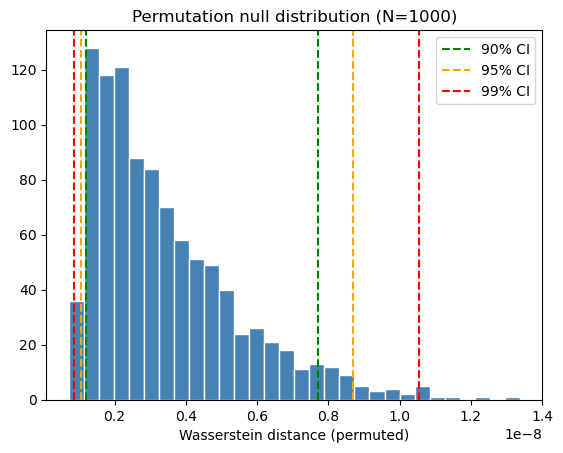

Observed Wasserstein Distance: 1.5353571077851977e-06
90% CI: [1.211780455342006e-09, 7.706247542182172e-09]
95% CI: [1.0687793027673806e-09, 8.695843837717243e-09]
99% CI: [8.652665826268937e-10, 1.055950831966581e-08]


In [26]:
permutation_test(data1, data2, N=1000)